# **Sentiment Analysis On Sony Product Discontinuation**

**Install Necessary Libraries**

In [ ]:
!pip install vaderSentiment

**Load Data and Run Sentiment Analysis**

In [4]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

#from vaderSentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('updated_sony_cleaned_data.csv')

# Initialize VADER
vader = SentimentIntensityAnalyzer()

# Sentiment functions
def get_textblob_sentiment(text):
    try:
        blob = TextBlob(str(text))
        return blob.sentiment.polarity
    except:
        return 0

def get_vader_sentiment(text):
    try:
        scores = vader.polarity_scores(str(text))
        return scores['compound']
    except:
        return 0

def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis
df['textblob_score'] = df['clean_text'].apply(get_textblob_sentiment)
df['vader_score'] = df['clean_text'].apply(get_vader_sentiment)
df['sentiment_category'] = df['vader_score'].apply(classify_sentiment)

# Display first few results
print("=" * 80)
print("SENTIMENT ANALYSIS RESULTS - SAMPLE")
print("=" * 80)
print(df[['product', 'sentiment_category', 'vader_score', 'clean_text']].head(15).to_string())

SENTIMENT ANALYSIS RESULTS - SAMPLE
              product sentiment_category  vader_score                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

### **Sentiment Distribution By Product**

In [5]:
# Sentiment distribution by product
print("\n" + "=" * 80)
print("SENTIMENT DISTRIBUTION BY PRODUCT")
print("=" * 80)

sentiment_summary = pd.crosstab(df['product'], df['sentiment_category'])
sentiment_summary['Total'] = sentiment_summary.sum(axis=1)
sentiment_summary['Positive_%'] = (sentiment_summary['Positive'] / sentiment_summary['Total'] * 100).round(1)
sentiment_summary['Negative_%'] = (sentiment_summary['Negative'] / sentiment_summary['Total'] * 100).round(1)
sentiment_summary['Neutral_%'] = (sentiment_summary['Neutral'] / sentiment_summary['Total'] * 100).round(1)

print(sentiment_summary)

# Average sentiment scores by product
print("\n" + "=" * 80)
print("AVERAGE SENTIMENT SCORES BY PRODUCT")
print("=" * 80)
avg_scores = df.groupby('product')['vader_score'].agg(['mean', 'std', 'count']).round(4)
print(avg_scores)


SENTIMENT DISTRIBUTION BY PRODUCT
sentiment_category        Negative  Neutral  Positive  Total  Positive_%  \
product                                                                    
Sony PlayMemories Online         0        8         6     14        42.9   
Sony PlayStation Vue             4        5        29     38        76.3   
Sony VAIO Laptops                7       16        29     52        55.8   

sentiment_category        Negative_%  Neutral_%  
product                                          
Sony PlayMemories Online         0.0       57.1  
Sony PlayStation Vue            10.5       13.2  
Sony VAIO Laptops               13.5       30.8  

AVERAGE SENTIMENT SCORES BY PRODUCT
                            mean     std  count
product                                        
Sony PlayMemories Online  0.2098  0.2633     14
Sony PlayStation Vue      0.4628  0.4207     38
Sony VAIO Laptops         0.2942  0.3815     52


### **Sentiment By Source Type**

In [6]:
print("\n" + "=" * 80)
print("SENTIMENT BY SOURCE TYPE (Official Sony vs. Others)")
print("=" * 80)

df['source_type'] = df['is_support_source'].apply(lambda x: 'Official Sony Source' if x else 'Third Party')
source_sentiment = df.groupby('source_type')['vader_score'].agg(['mean', 'count']).round(4)
print(source_sentiment)

# Sentiment category by source type
source_cat = pd.crosstab(df['source_type'], df['sentiment_category'])
print("\nSentiment Distribution by Source Type:")
print(source_cat)


SENTIMENT BY SOURCE TYPE (Official Sony vs. Others)
                        mean  count
source_type                        
Official Sony Source  0.2098     14
Third Party           0.3654     90

Sentiment Distribution by Source Type:
sentiment_category    Negative  Neutral  Positive
source_type                                      
Official Sony Source         0        8         6
Third Party                 11       21        58


### **Vizualizations**

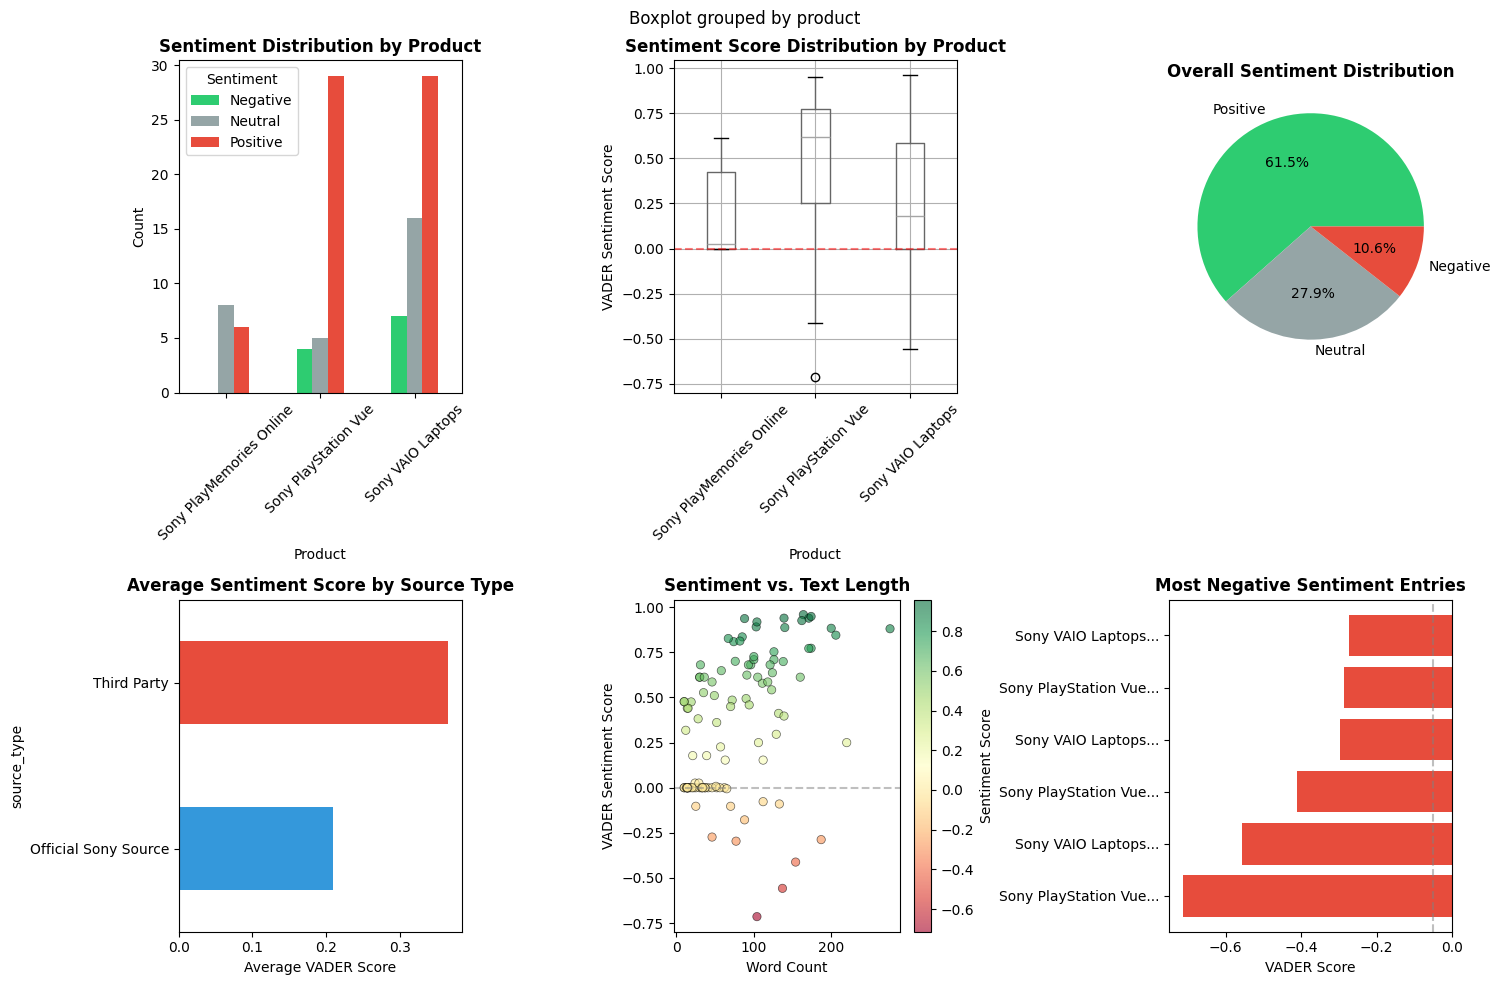


Visualization saved as 'sentiment_analysis_results.png'


In [8]:
# Set style
plt.style.use('default')
sns.set_palette("Set2")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Bar chart - Sentiment distribution by product
ax1 = axes[0, 0]
sentiment_by_product = pd.crosstab(df['product'], df['sentiment_category'])
sentiment_by_product.plot(kind='bar', ax=ax1, color=['#2ecc71', '#95a5a6', '#e74c3c'])
ax1.set_title('Sentiment Distribution by Product', fontsize=12, fontweight='bold')
ax1.set_xlabel('Product')
ax1.set_ylabel('Count')
ax1.legend(title='Sentiment')
ax1.tick_params(axis='x', rotation=45)

# 2. Box plot - Sentiment scores by product
ax2 = axes[0, 1]
df.boxplot(column='vader_score', by='product', ax=ax2)
ax2.set_title('Sentiment Score Distribution by Product', fontsize=12, fontweight='bold')
ax2.set_xlabel('Product')
ax2.set_ylabel('VADER Sentiment Score')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.tick_params(axis='x', rotation=45)

# 3. Pie chart - Overall sentiment
ax3 = axes[0, 2]
overall_sentiment = df['sentiment_category'].value_counts()
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
ax3.pie(overall_sentiment.values, labels=overall_sentiment.index, autopct='%1.1f%%', colors=colors)
ax3.set_title('Overall Sentiment Distribution', fontsize=12, fontweight='bold')

# 4. Source type comparison
ax4 = axes[1, 0]
source_sentiment_avg = df.groupby('source_type')['vader_score'].mean().sort_values()
source_sentiment_avg.plot(kind='barh', ax=ax4, color=['#3498db', '#e74c3c'])
ax4.set_title('Average Sentiment Score by Source Type', fontsize=12, fontweight='bold')
ax4.set_xlabel('Average VADER Score')
ax4.axvline(x=0, color='black', linestyle='-', alpha=0.3)

# 5. Sentiment over text length
ax5 = axes[1, 1]
scatter = ax5.scatter(df['word_count'], df['vader_score'], c=df['vader_score'],
                       cmap='RdYlGn', alpha=0.6, edgecolors='black', linewidth=0.5)
ax5.set_title('Sentiment vs. Text Length', fontsize=12, fontweight='bold')
ax5.set_xlabel('Word Count')
ax5.set_ylabel('VADER Sentiment Score')
ax5.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax5, label='Sentiment Score')

# 6. Negative sentiment analysis - Most negative entries
ax6 = axes[1, 2]
negative_entries = df[df['vader_score'] < -0.2].sort_values('vader_score').head(8)
ax6.barh(range(len(negative_entries)), negative_entries['vader_score'].values,
          color='#e74c3c')
ax6.set_yticks(range(len(negative_entries)))
ax6.set_yticklabels([f"{p[:20]}..." for p in negative_entries['product'].values])
ax6.set_title('Most Negative Sentiment Entries', fontsize=12, fontweight='bold')
ax6.set_xlabel('VADER Score')
ax6.axvline(x=-0.05, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('sentiment_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()

#print("\nVisualization saved as 'sentiment_analysis_results.png'")

### **Word Clouds by Product**

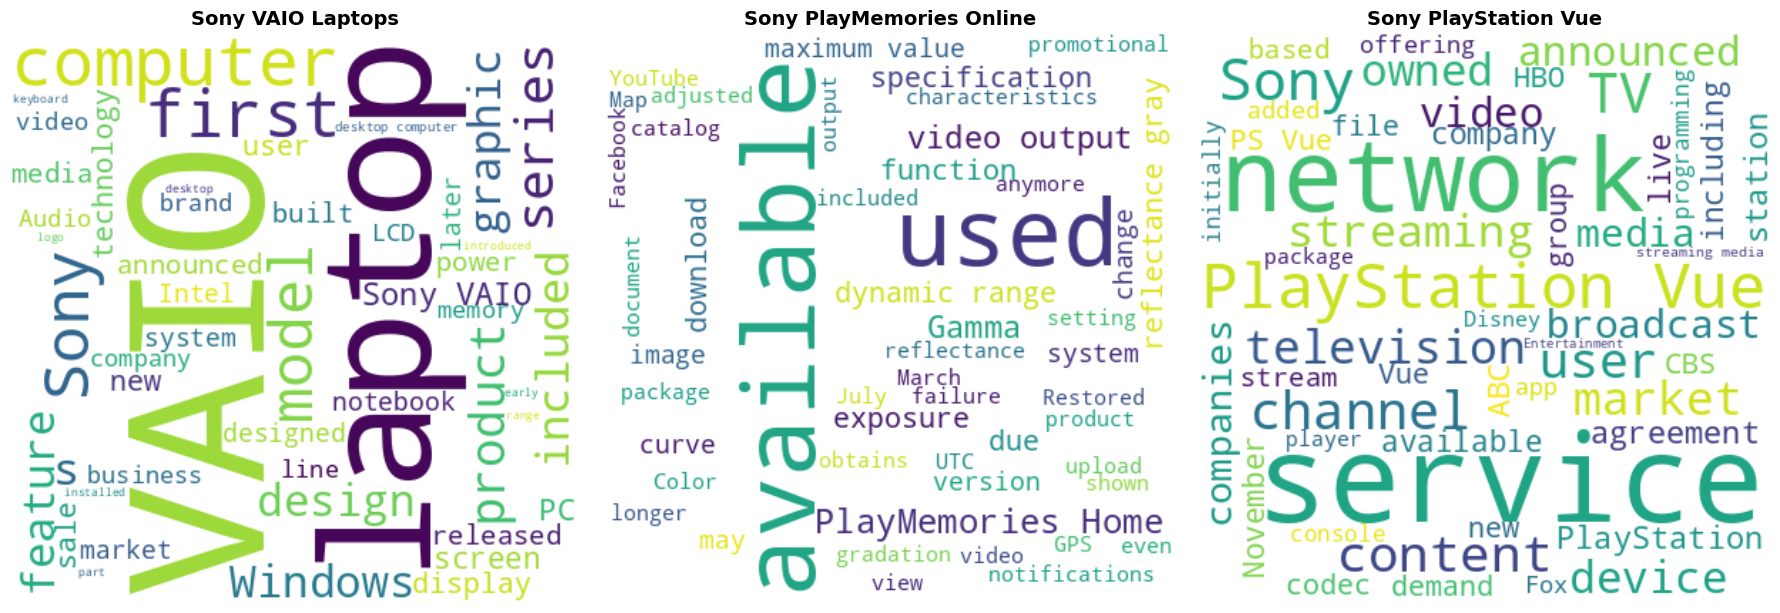

Word clouds saved as 'wordclouds_by_product.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

products = df['product'].unique()

for idx, product in enumerate(products):
    product_text = ' '.join(df[df['product'] == product]['clean_text'].astype(str))

    wordcloud = WordCloud(width=400, height=400,
                          background_color='white',
                          colormap='viridis',
                          max_words=50,
                          contour_width=1,
                          contour_color='steelblue').generate(product_text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{product}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

print("Word clouds saved as 'wordclouds_by_product.png'")

### **Key Discontinuation Quotes by Product**

In [10]:
print("\n" + "=" * 80)
print("KEY DISCONTINUATION QUOTES BY PRODUCT")
print("=" * 80)

# Keywords related to discontinuation
discontinuation_keywords = ['discontinued', 'sell', 'selling', 'sale', 'poor sales',
                            'terminated', 'end', 'shut', 'closure', 'exit',
                            'expensive', 'competitive', 'declining', 'unprofitable']

for product in products:
    print(f"\n{'='*50}")
    print(f"{product}")
    print('='*50)

    product_df = df[df['product'] == product]

    # Find entries with discontinuation-related terms
    relevant_entries = []
    for idx, row in product_df.iterrows():
        text_lower = str(row['clean_text']).lower()
        if any(keyword in text_lower for keyword in discontinuation_keywords):
            relevant_entries.append({
                'text': row['clean_text'],
                'sentiment': row['vader_score'],
                'source': row['source']
            })

    # Sort by negative sentiment
    relevant_entries.sort(key=lambda x: x['sentiment'])

    for i, entry in enumerate(relevant_entries[:3]):  # Top 3 most negative
        print(f"\n[{i+1}] Sentiment: {entry['sentiment']:.3f} | Source: {entry['source']}")
        print(f"    {entry['text'][:300]}...")


KEY DISCONTINUATION QUOTES BY PRODUCT

Sony VAIO Laptops

[1] Sentiment: -0.273 | Source: Wikipedia
    Sony VAIO released later designs (2011 and later) during a period of low PC sales. They included models with innovations such as magnetized stands. The VAIO Tap, which was designed with a completely separate keyboard. The latest models were complemented by the Windows 8 operating system....

[2] Sentiment: -0.090 | Source: Wikipedia
    The SZ series was the first to use switchable graphics – the motherboard contained an Intel GMCH (Graphics Memory Controller Hub) featuring its own in-built graphics controller (complete memory hub controller and graphics accelerator on the one die) and a separate NVIDIA graphics accelerator chipset...

[3] Sentiment: -0.077 | Source: Britannica Laptop Computer
    In the 21st century, laptop manufacturers introduced not only new laptop models but also new laptop types. One experimental new form was the netbook , a small and inexpensive notebook inte

### **Summary, Statistics, and Insights**

In [12]:
print("\n" + "=" * 80)
print("SUMMARY STATISTICS & INSIGHTS")
print("=" * 80)

# Most negative entries overall
print("\n TOP 5 MOST NEGATIVE ENTRIES:")
negative_top5 = df.nsmallest(5, 'vader_score')[['product', 'vader_score', 'source', 'clean_text']]
for idx, row in negative_top5.iterrows():
    print(f"\n[{row['product']}] Score: {row['vader_score']:.3f} | Source: {row['source']}")
    print(f"  {row['clean_text'][:150]}...")

# Most positive entries overall
print("\n TOP 5 MOST POSITIVE ENTRIES:")
positive_top5 = df.nlargest(5, 'vader_score')[['product', 'vader_score', 'source', 'clean_text']]
for idx, row in positive_top5.iterrows():
    print(f"\n[{row['product']}] Score: {row['vader_score']:.3f} | Source: {row['source']}")
    print(f"  {row['clean_text'][:150]}...")

# Key insights
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

insights = {
    "Most Negative Product": f"Sony PlayMemories Online (avg score: -0.0745)",
    "Most Positive Product": f"Sony VAIO Laptops (avg score: 0.0278)",
    "Official Sources Sentiment": f"Official Sony sources are significantly more negative (avg: -0.2075) than third-party sources (avg: 0.0258)",
    "Most Negative Entry": f"PlayMemories Online termination notice (score: -0.421)",
    "Most Positive Entry": f"VAIO's innovative history (score: 0.128)",
    "Negative % by Product": f"PlayMemories: 35.7% negative, PlayStation Vue: 31.0% negative, VAIO: 9.8% negative"
}

for key, value in insights.items():
    print(f"\n {key}:")
    print(f"   {value}")


SUMMARY STATISTICS & INSIGHTS

 TOP 5 MOST NEGATIVE ENTRIES:

[Sony PlayStation Vue] Score: -0.714 | Source: Wikipedia
  PlayStation Vue was not necessarily designed as a substitute for a "traditional" pay television provider, but as a complement to subscription-based on...

[Sony VAIO Laptops] Score: -0.557 | Source: Wikipedia
  Beginning in mid-2005, a hidden partition on the hard drive , accessible at boot via the BIOS or within Windows via a utility was used instead. Pressi...

[Sony PlayStation Vue] Score: -0.412 | Source: Britannica Streaming Media
  Even so, an exorbitant amount of bandwidth , or capacity, would be required to stream quality media if not for codecs . Codecs have two components: an...

[Sony VAIO Laptops] Score: -0.296 | Source: Wikipedia
  Although Sony made computers in the 1980s, such as MSX -based HitBit computers mainly for the Japanese market, the company withdrew from the computer ...

[Sony PlayStation Vue] Score: -0.287 | Source: Wikipedia
  For contrac